# 05 — Model Architecture & Training

Define a lightweight CNN, train it with PyTorch Lightning, and evaluate on the held-out test set.

### Architecture

The spectrogram `(1, 64, 216)` is treated as a grayscale image and passed through a 2D CNN. The architecture is intentionally small to train in reasonable time on CPU.

```
Input  (1, 64, 216)
  Conv2d(1->32,   3x3) + BN + ReLU + MaxPool(2x2)    -> (32, 32, 108)
  Conv2d(32->64,  3x3) + BN + ReLU + MaxPool(2x2)    -> (64, 16, 54)
  Conv2d(64->128, 3x3) + BN + ReLU + MaxPool(2x2)    -> (128, 8, 27)
  Conv2d(128->128,3x3) + BN + ReLU + AdaptiveAvgPool -> (128, 4, 4)
  Flatten -> (2048,)
  Dropout(0.5)
  Linear(2048->256) + ReLU
  Dropout(0.3)
  Linear(256->10)   -> logits
```

~2M parameters. Trains in roughly 30 to 60 minutes on CPU for 30 epochs.

### Training setup

- Loss: CrossEntropyLoss with inverse-frequency class weights
- Optimiser: Adam, lr=1e-3
- Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
- Early stopping: patience=10 on val loss
- Logging: TensorBoard + CSV


## 0. Imports & configuration


In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
pl.seed_everything(SEED, workers=True)
print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Seed set to 42


PyTorch  : 2.10.0+cpu
Lightning: 2.6.1
Device   : cpu


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT         = Path("data")
MANIFEST_CSV = ROOT / "features_manifest.csv"
CKPT_DIR     = Path("checkpoints")
LOG_DIR      = Path("logs")
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
IDX2CLASS = {v: k for k, v in CLASS2IDX.items()}
CLASSES   = list(CLASS2IDX.keys())
N_CLASSES = len(CLASSES)

# ── Training config ───────────────────────────────────────────────────────────
FEATURE_TYPE  = 'logmel'   # 'logmel' or 'pcen'
BATCH_SIZE    = 32
NUM_WORKERS   = 0          # keep 0 on Windows
MAX_EPOCHS    = 50
LEARNING_RATE = 1e-3

# ── Input shape ───────────────────────────────────────────────────────────────
N_MELS   = 64
T_FRAMES = 216

print(f"Feature   : {FEATURE_TYPE}")
print(f"Max epochs: {MAX_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")

Feature   : logmel
Max epochs: 50
Batch size: 32


---
## 1. Dataset & DataModule

Copied from Notebook 04 so this notebook is self-contained.


In [4]:
class AudioDataset(Dataset):
    def __init__(self, df, feat_col, mean, std, augment=False,
                 time_mask_p=30, freq_mask_p=10):
        self.paths       = df[feat_col].tolist()
        self.labels      = df['label_idx'].tolist()
        self.mean        = torch.from_numpy(mean).unsqueeze(0)
        self.std         = torch.from_numpy(std).unsqueeze(0)
        self.augment     = augment
        self.time_mask_p = time_mask_p
        self.freq_mask_p = freq_mask_p

    def __len__(self):  return len(self.paths)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.load(self.paths[idx])).unsqueeze(0)
        x = (x - self.mean) / (self.std + 1e-6)
        if self.augment:
            x = self._mask(x, self.time_mask_p, dim=2)
            x = self._mask(x, self.freq_mask_p, dim=1)
        return x, torch.tensor(self.labels[idx], dtype=torch.long)

    @staticmethod
    def _mask(x, max_len, dim):
        size = x.shape[dim]
        t    = torch.randint(0, max_len, (1,)).item()
        t0   = torch.randint(0, max(1, size - t), (1,)).item()
        if dim == 2:  x[:, :, t0:t0+t] = 0.0
        else:         x[:, t0:t0+t, :] = 0.0
        return x


class AudioDataModule(pl.LightningDataModule):
    def __init__(self, manifest_csv, feature_type='logmel',
                 batch_size=32, num_workers=0, augment_train=True):
        super().__init__()
        self.manifest_csv  = Path(manifest_csv)
        self.feature_type  = feature_type
        self.feat_col      = f'{feature_type}_path'
        self.stats_path    = self.manifest_csv.parent / f'norm_stats_{feature_type}.npz'
        self.batch_size    = batch_size
        self.num_workers   = num_workers
        self.augment_train = augment_train

    def setup(self, stage=None):
        manifest = pd.read_csv(self.manifest_csv)
        manifest[self.feat_col] = manifest[self.feat_col].apply(lambda p: str(Path(p)))
        stats = np.load(self.stats_path)
        mean, std = stats['mean'], stats['std']
        self.train_ds = AudioDataset(manifest[manifest['split']=='train'].reset_index(drop=True),
                                     self.feat_col, mean, std, augment=self.augment_train)
        self.val_ds   = AudioDataset(manifest[manifest['split']=='val'].reset_index(drop=True),
                                     self.feat_col, mean, std, augment=False)
        self.test_ds  = AudioDataset(manifest[manifest['split']=='test'].reset_index(drop=True),
                                     self.feat_col, mean, std, augment=False)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True, num_workers=self.num_workers)
    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers)
    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers)

print("OK: Dataset & DataModule defined")

OK: Dataset & DataModule defined


---
## 2. Class weights

Bus, MC, and Horn are under-represented relative to the capped classes. Inverse-frequency weights are passed to CrossEntropyLoss so that errors on rare classes contribute more to the gradient.


In [5]:
manifest   = pd.read_csv(MANIFEST_CSV)
train_df   = manifest[manifest['split'] == 'train']
label_counts = train_df['label_idx'].value_counts().sort_index()

# Inverse-frequency weights, normalised to mean=1
counts  = torch.tensor(label_counts.values, dtype=torch.float)
weights = 1.0 / counts
weights = weights / weights.mean()

print("Class weights for CrossEntropyLoss:")
for idx, w in enumerate(weights):
    print(f"  {IDX2CLASS[idx]:<15} n={int(counts[idx]):>4}   weight={w:.3f}")

Class weights for CrossEntropyLoss:
  BG              n= 699   weight=0.717
  MC              n= 475   weight=1.055
  Car             n= 700   weight=0.716
  Bus             n= 260   weight=1.927
  Truck           n= 700   weight=0.716
  Tram            n= 503   weight=0.996
  Horn            n= 300   weight=1.670
  Dog             n= 700   weight=0.716
  Construction    n= 700   weight=0.716
  Siren           n= 650   weight=0.771


---
## 3. Model architecture

### 3a. CNN building blocks


In [6]:
class ConvBlock(nn.Module):
    """Conv2d -> BatchNorm -> ReLU -> MaxPool."""
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
        )
    def forward(self, x): return self.block(x)


class AudioCNN(nn.Module):
    """
    Lightweight 2D CNN for spectrogram classification.
    Input : (B, 1, 64, 216)
    Output: (B, n_classes) logits
    """
    def __init__(self, n_classes: int = 10, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,    32,  pool=(2, 2)),   # -> (32, 32, 108)
            ConvBlock(32,   64,  pool=(2, 2)),   # -> (64, 16, 54)
            ConvBlock(64,  128,  pool=(2, 2)),   # -> (128, 8, 27)
            ConvBlock(128, 128,  pool=(2, 2)),   # -> (128, 4, 13)
            nn.AdaptiveAvgPool2d((4, 4)),         # -> (128, 4, 4)  fixed regardless of input size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(256, n_classes),
        )

    def forward(self, x): return self.classifier(self.features(x))


# ── Parameter count ───────────────────────────────────────────────────────────
model = AudioCNN(n_classes=N_CLASSES)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"AudioCNN -- trainable parameters: {n_params:,}")

# ── Shape check ───────────────────────────────────────────────────────────────
dummy = torch.zeros(2, 1, N_MELS, T_FRAMES)
out   = model(dummy)
print(f"Input shape : {tuple(dummy.shape)}")
print(f"Output shape: {tuple(out.shape)}   <- (batch, n_classes)")

AudioCNN -- trainable parameters: 767,722
Input shape : (2, 1, 64, 216)
Output shape: (2, 10)   <- (batch, n_classes)


### 3b. Architecture summary


In [7]:
print(model)

AudioCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_ru

---
## 4. PyTorch Lightning module

`AudioClassifier` wraps the CNN with weighted cross-entropy loss, an Adam optimiser, a ReduceLROnPlateau scheduler, and per-epoch accuracy logging.


In [8]:
class AudioClassifier(pl.LightningModule):
    """
    PyTorch Lightning wrapper around AudioCNN.

    Args:
        n_classes    : Number of output classes
        class_weights: 1D tensor of per-class loss weights
        lr           : Initial learning rate
        dropout      : Dropout rate in the classifier head
    """
    def __init__(self, n_classes=10, class_weights=None, lr=1e-3, dropout=0.5):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.model     = AudioCNN(n_classes=n_classes, dropout=dropout)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.lr        = lr

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(self, x): return self.model(x)

    # ── Shared step ───────────────────────────────────────────────────────────
    def _step(self, batch, stage: str):
        x, y    = batch
        logits  = self(x)
        loss    = self.criterion(logits, y)
        preds   = logits.argmax(dim=1)
        acc     = (preds == y).float().mean()
        self.log(f'{stage}_loss', loss, on_epoch=True, on_step=False,
                 prog_bar=True, logger=True)
        self.log(f'{stage}_acc',  acc,  on_epoch=True, on_step=False,
                 prog_bar=True, logger=True)
        return loss

    def training_step(self,   batch, _): return self._step(batch, 'train')
    def validation_step(self, batch, _): return self._step(batch, 'val')
    def test_step(self,       batch, _): return self._step(batch, 'test')

    # ── Optimiser & scheduler ─────────────────────────────────────────────────
    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=5  # verbose supprimé
        )
        return {
            'optimizer': opt,
            'lr_scheduler': {'scheduler': sch, 'monitor': 'val_loss'}
        }

print("OK: AudioClassifier defined")

OK: AudioClassifier defined


---
## 5. Training

### 5a. Instantiate everything


In [9]:
# ── DataModule ────────────────────────────────────────────────────────────────
dm = AudioDataModule(
    manifest_csv  = MANIFEST_CSV,
    feature_type  = FEATURE_TYPE,
    batch_size    = BATCH_SIZE,
    num_workers   = NUM_WORKERS,
    augment_train = True,
)
dm.setup()

# ── Model ─────────────────────────────────────────────────────────────────────
lit_model = AudioClassifier(
    n_classes     = N_CLASSES,
    class_weights = weights,     # computed in Section 2
    lr            = LEARNING_RATE,
    dropout       = 0.5,
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, mode='min', verbose=True
)
checkpoint = ModelCheckpoint(
    dirpath   = CKPT_DIR,
    filename  = f'{FEATURE_TYPE}_best',
    monitor   = 'val_acc',
    mode      = 'max',
    save_top_k = 1,
    verbose   = True,
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# ── Loggers ───────────────────────────────────────────────────────────────────
tb_logger  = TensorBoardLogger(save_dir=LOG_DIR, name=f'cnn_{FEATURE_TYPE}')
csv_logger = CSVLogger(save_dir=LOG_DIR, name=f'cnn_{FEATURE_TYPE}')

print("OK: Everything instantiated -- ready to train")

OK: Everything instantiated -- ready to train


### 5b. Train

Expected runtime on CPU: roughly 1 to 2 minutes per epoch. Early stopping typically triggers around epoch 20 to 30.


In [10]:
trainer = pl.Trainer(
    max_epochs        = MAX_EPOCHS,
    accelerator       = 'cpu',
    callbacks         = [early_stop, checkpoint, lr_monitor],
    logger            = [tb_logger, csv_logger],
    log_every_n_steps = 10,
    deterministic     = True,
)

trainer.fit(lit_model, datamodule=dm)
print(f"\nOK: Training complete -- best checkpoint: {checkpoint.best_model_path}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\anyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\anyal\Desktop\S8\Pole_ProjetS8\checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ AudioCNN         │  767 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 767 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 767 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\anyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, 
use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

Epoch 46, global step 8366: 'val_acc' reached 0.89910 (best 0.89910), saving model to 'C:\\Users\\anyal\\Desktop\\S8\\Pole_ProjetS8\\checkpoints\\logmel_best-v2.ckpt' as top 1


Epoch 47, global step 8544: 'val_acc' was not in top 1


Epoch 48, global step 8722: 'val_acc' was not in top 1


Epoch 49, global step 8900: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.



OK: Training complete -- best checkpoint: C:\Users\anyal\Desktop\S8\Pole_ProjetS8\checkpoints\logmel_best-v2.ckpt


---
## 6. Training curves

Loss and accuracy over epochs, read from the CSV logger.


In [11]:
# Find the CSV log file written by CSVLogger
csv_log_path = sorted(
    (LOG_DIR / f'cnn_{FEATURE_TYPE}').rglob('metrics.csv')
)[-1]
print(f"Reading logs from: {csv_log_path}")

logs = pd.read_csv(csv_log_path)
print(f"Columns: {list(logs.columns)}")
logs.head()

Reading logs from: logs\cnn_logmel\version_7\metrics.csv
Columns: ['epoch', 'lr-Adam', 'step', 'train_acc', 'train_loss', 'val_acc', 'val_loss']


,epoch,lr-Adam,step,train_acc,train_loss,val_acc,val_loss
0,NaN,0.001,0,NaN,NaN,NaN,NaN
1,0.0,NaN,177,NaN,NaN,0.655455,0.886347
2,0.0,NaN,177,0.547213,1.207986,NaN,NaN
3,NaN,0.001,178,NaN,NaN,NaN,NaN
4,1.0,NaN,355,NaN,NaN,0.753076,0.704950


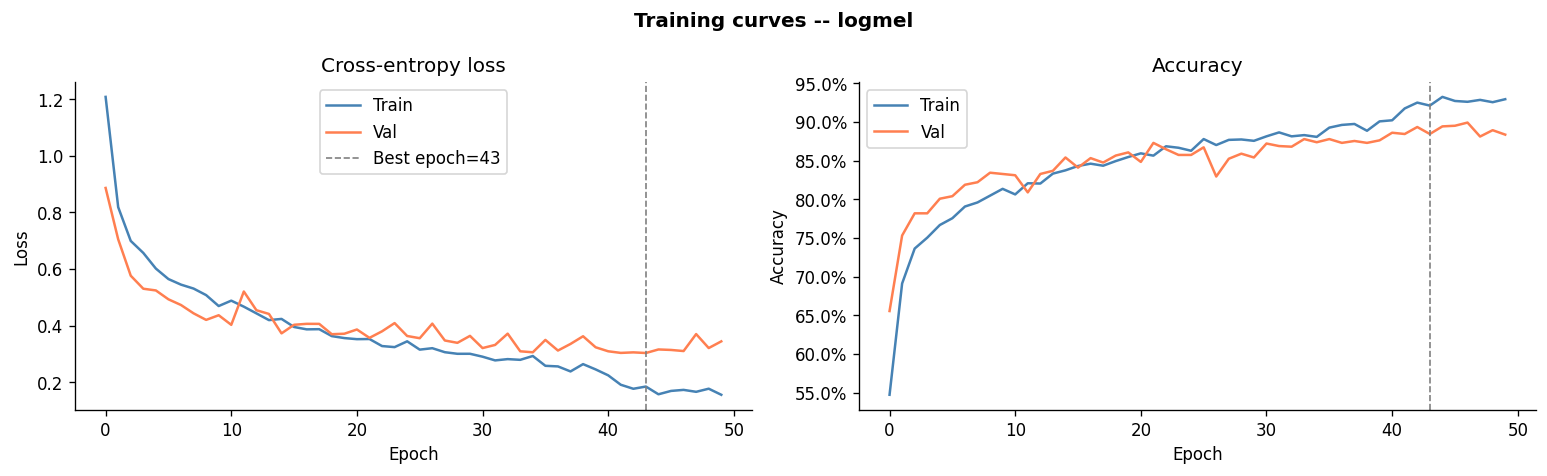

Best val accuracy : 0.899  (89.9%)
Best val loss     : 0.3033
Best epoch        : 43


In [12]:
# Separate train and val rows (Lightning logs them at different steps)
train_logs = logs.dropna(subset=['train_loss']).copy()
val_logs   = logs.dropna(subset=['val_loss']).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Training curves -- {FEATURE_TYPE}', fontweight='bold')

# Loss
axes[0].plot(train_logs['epoch'], train_logs['train_loss'],
             label='Train', color='steelblue', linewidth=1.5)
axes[0].plot(val_logs['epoch'], val_logs['val_loss'],
             label='Val', color='coral', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-entropy loss')
axes[0].legend()
best_epoch = val_logs.loc[val_logs['val_loss'].idxmin(), 'epoch']
axes[0].axvline(best_epoch, color='gray', linestyle='--',
                linewidth=1, label=f'Best epoch={int(best_epoch)}')
axes[0].legend()

# Accuracy
axes[1].plot(train_logs['epoch'], train_logs['train_acc'],
             label='Train', color='steelblue', linewidth=1.5)
axes[1].plot(val_logs['epoch'], val_logs['val_acc'],
             label='Val', color='coral', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1)
axes[1].legend()

plt.tight_layout()
plt.savefig('05_training_curves.png', bbox_inches='tight')
plt.show()

best_val_acc  = val_logs['val_acc'].max()
best_val_loss = val_logs['val_loss'].min()
print(f"Best val accuracy : {best_val_acc:.3f}  ({best_val_acc*100:.1f}%)")
print(f"Best val loss     : {best_val_loss:.4f}")
print(f"Best epoch        : {int(best_epoch)}")

---
## 7. Evaluation on the test set

Load the best checkpoint and run inference on the held-out test set.


In [13]:
# Load best checkpoint
best_model = AudioClassifier.load_from_checkpoint(
    checkpoint.best_model_path,
    n_classes     = N_CLASSES,
    class_weights = weights,
)
best_model.eval()

# Run test set
results = trainer.test(best_model, datamodule=dm, verbose=True)
print(f"\nTest accuracy: {results[0]['test_acc']:.3f}  ({results[0]['test_acc']*100:.1f}%)")

Output()

C:\Users\anyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\anyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8982772827148438     │
│         test_loss         │    0.32957521080970764    │
└───────────────────────────┴───────────────────────────┘


Test accuracy: 0.898  (89.8%)


### 7a. Confusion matrix


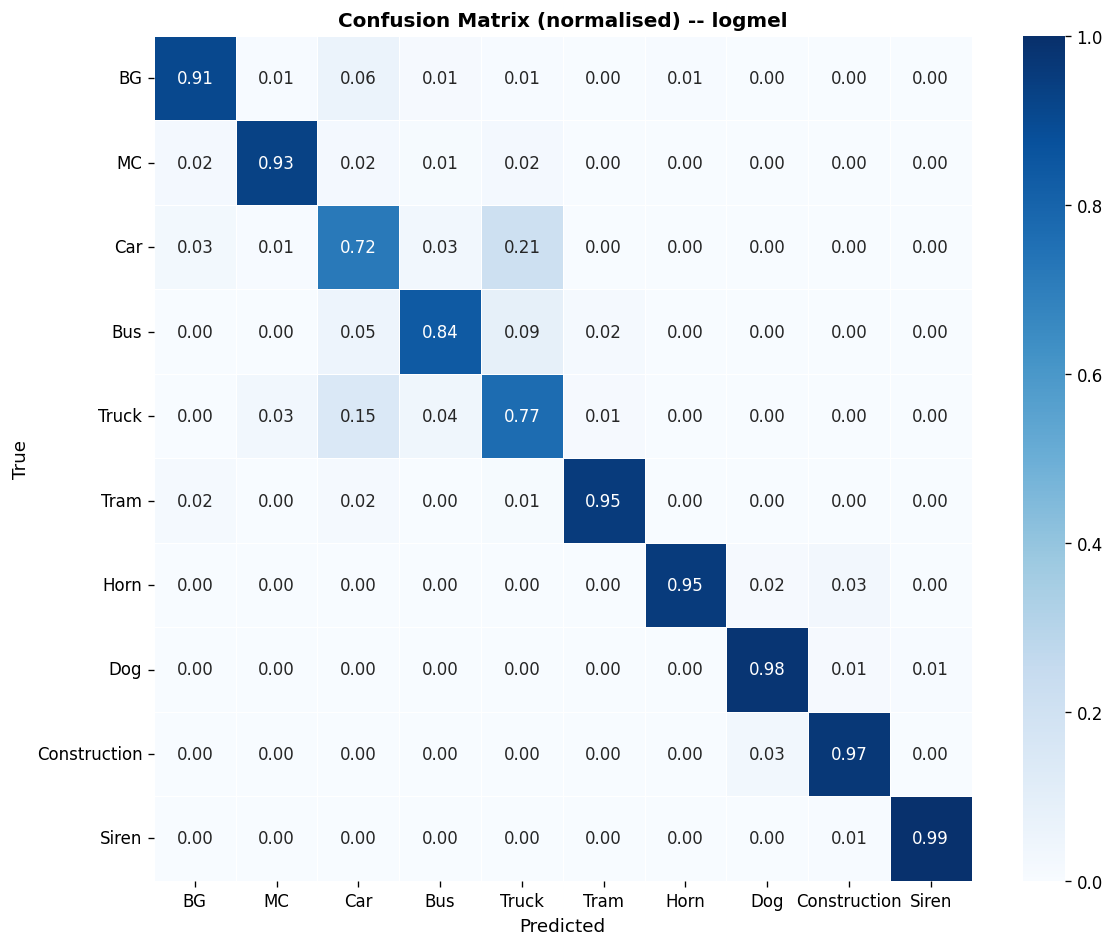

In [14]:
# Collect all predictions on the test set
all_preds, all_labels = [], []

best_model.eval()
with torch.no_grad():
    for x, y in dm.test_dataloader():
        logits = best_model(x)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
# Normalise per true class (row)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title(f'Confusion Matrix (normalised) -- {FEATURE_TYPE}', fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight')
plt.show()

### 7b. Per-class classification report


              precision    recall  f1-score   support

          BG      0.944     0.907     0.925       150
          MC      0.931     0.931     0.931       102
         Car      0.740     0.720     0.730       150
         Bus      0.770     0.839     0.803        56
       Truck      0.737     0.767     0.752       150
        Tram      0.971     0.953     0.962       107
        Horn      0.984     0.954     0.969        65
         Dog      0.961     0.980     0.970       150
Construction      0.967     0.967     0.967       150
       Siren      0.993     0.993     0.993       139

    accuracy                          0.898      1219
   macro avg      0.900     0.901     0.900      1219
weighted avg      0.899     0.898     0.899      1219



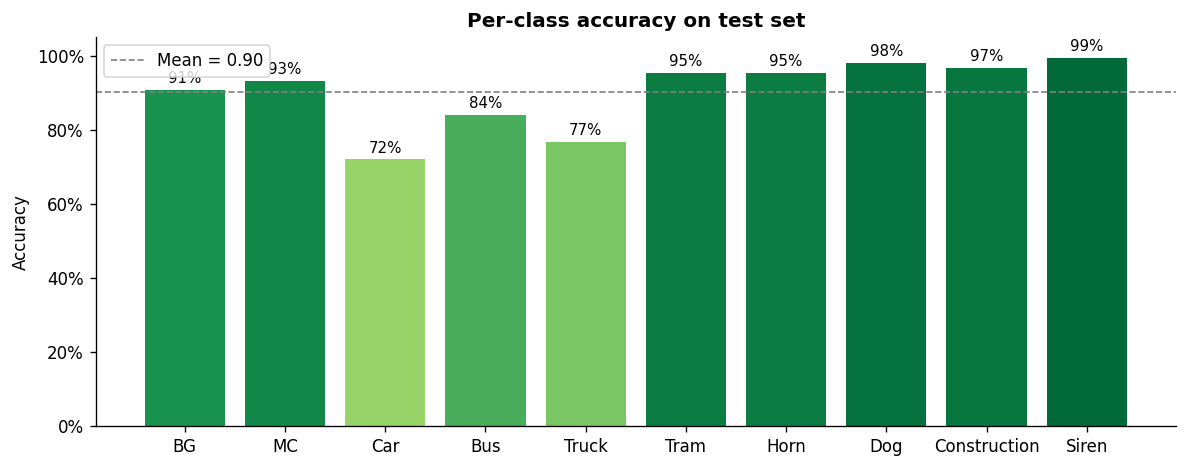

In [15]:
report = classification_report(
    all_labels, all_preds,
    target_names=CLASSES, digits=3
)
print(report)

# Per-class accuracy bar chart
per_class_acc = cm_norm.diagonal()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASSES, per_class_acc,
              color=[plt.cm.RdYlGn(v) for v in per_class_acc])
ax.axhline(per_class_acc.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Mean = {per_class_acc.mean():.2f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Per-class accuracy on test set', fontweight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('05_per_class_accuracy.png', bbox_inches='tight')
plt.show()

---
## 8. Summary


In [16]:
overall_acc = (all_preds == all_labels).mean()

print("=" * 55)
print("TRAINING SUMMARY")
print("=" * 55)
print(f"  Feature type     : {FEATURE_TYPE}")
print(f"  Architecture     : AudioCNN  ({n_params:,} params)")
print(f"  Epochs trained   : {int(best_epoch)} / {MAX_EPOCHS}")
print(f"  Best val acc     : {best_val_acc:.3f}  ({best_val_acc*100:.1f}%)")
print(f"  Test accuracy    : {overall_acc:.3f}  ({overall_acc*100:.1f}%)")
print(f"  Best checkpoint  : {checkpoint.best_model_path}")
print()
print("  Per-class test accuracy:")
for cls, acc in zip(CLASSES, per_class_acc):
    flag = '  [low]' if acc < 0.5 else ''
    print(f"    {cls:<15} {acc:.0%}{flag}")


TRAINING SUMMARY
  Feature type     : logmel
  Architecture     : AudioCNN  (767,722 params)
  Epochs trained   : 43 / 50
  Best val acc     : 0.899  (89.9%)
  Test accuracy    : 0.898  (89.8%)
  Best checkpoint  : C:\Users\anyal\Desktop\S8\Pole_ProjetS8\checkpoints\logmel_best-v2.ckpt

  Per-class test accuracy:
    BG              91%
    MC              93%
    Car             72%
    Bus             84%
    Truck           77%
    Tram            95%
    Horn            95%
    Dog             98%
    Construction    97%
    Siren           99%
